In [ ]:
from RoyalFunctions import compute_ac
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

/tmp/ipykernel_298318/3872054370.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('viridis', len(paths))


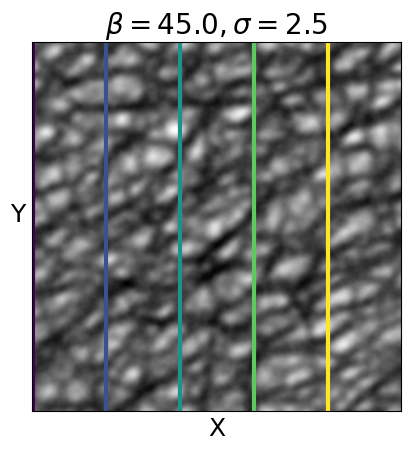

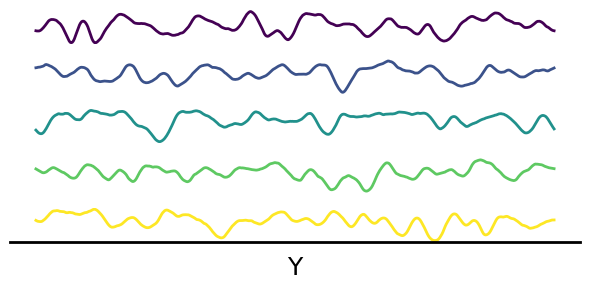

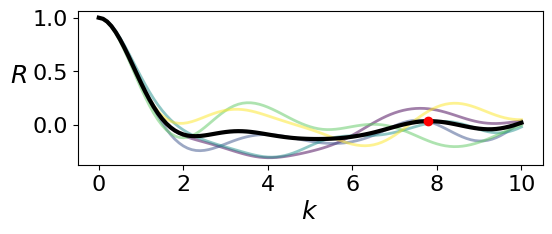

78
0.035890852975098794


In [2]:
beta = 45.0
sigma = 2.5
deviation = np.load(f'fig07/{sigma}_{beta}_{1}.npy')

fig = plt.figure()
plt.imshow(deviation, cmap='binary')

paths = [[2*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [100*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [200*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [300*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [400*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)]]

viridis = plt.cm.get_cmap('viridis', len(paths))

for i in range(len(paths)):
    plt.plot(paths[i][0], paths[i][1], c=viridis(i/len(paths)), lw=3)
plt.title(fr"$\beta = {beta},  \sigma = {sigma}$", fontsize=20)
plt.xlabel("X", fontsize=18)
plt.ylabel("Y", fontsize=18,rotation=0, labelpad=10)

# remove ticks and tick labels
ax = plt.gca()
ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

plt.show()


fig, axs = plt.subplots(nrows=5, figsize=(6,3), sharex=True, tight_layout=True)
for i in range(len(paths)): 
    axs[i].plot(deviation[:, i*100], c=viridis(i/len(paths)), lw=2)
    for side in ("top", "right", "left", "bottom"):
        axs[i].spines[side].set_visible(False)
    axs[i].tick_params(left=False, right=False, labelleft=False,
                   bottom=False, top=False, labelbottom=False)
axs[-1].spines["bottom"].set_visible(True)  
axs[-1].spines["bottom"].set_linewidth(2.0)
axs[-1].spines["bottom"].set_color("black")
plt.xlabel('Y', fontsize=18, labelpad=10)
plt.show()

corr, prominence, lag = compute_ac(deviation, paths, resolution=10, plot=True)   
print(lag)
print(corr)


/tmp/ipykernel_298318/1842398492.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('viridis', len(paths))


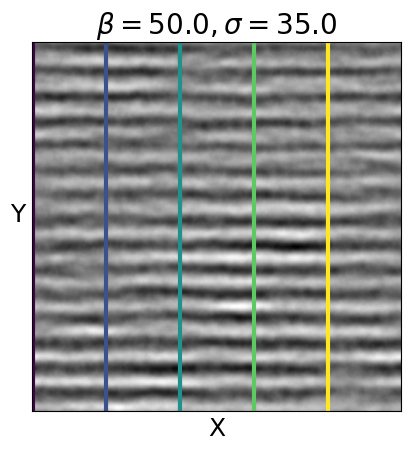

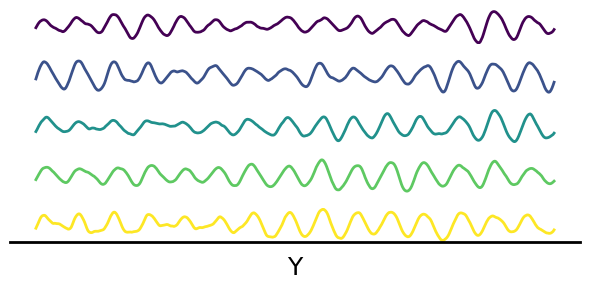

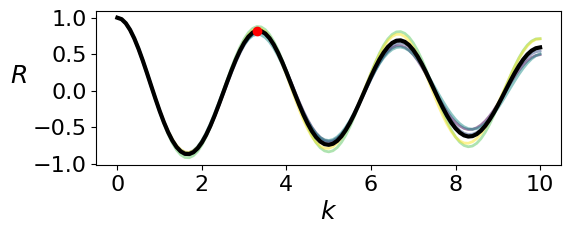

33
0.8223207292095985


In [4]:
beta = 50.0
sigma = 35.0
deviation = np.load(f'fig07/{sigma}_{beta}_{1}.npy')

fig = plt.figure()
plt.imshow(deviation, cmap='binary')

viridis = plt.cm.get_cmap('viridis', len(paths))

for i in range(len(paths)):
    plt.plot(paths[i][0], paths[i][1], c=viridis(i/len(paths)), lw=3)
plt.title(fr"$\beta = {beta},  \sigma = {sigma}$", fontsize=20)
plt.xlabel("X", fontsize=18)
plt.ylabel("Y", fontsize=18,rotation=0, labelpad=10)

# remove ticks and tick labels
ax = plt.gca()
ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

plt.show()

fig, axs = plt.subplots(nrows=5, figsize=(6,3), sharex=True, tight_layout=True)
for i in range(len(paths)): 
    axs[i].plot(deviation[:, i*100], c=viridis(i/len(paths)), lw=2)
    for side in ("top", "right", "left", "bottom"):
        axs[i].spines[side].set_visible(False)
    axs[i].tick_params(left=False, right=False, labelleft=False,
                   bottom=False, top=False, labelbottom=False)
axs[-1].spines["bottom"].set_visible(True)  
axs[-1].spines["bottom"].set_linewidth(2.0)
axs[-1].spines["bottom"].set_color("black")
plt.xlabel('Y', fontsize=18, labelpad=10)
plt.show()
  
corr, prominence, lag = compute_ac(deviation, paths, plot=True)   
print(lag)
print(corr)

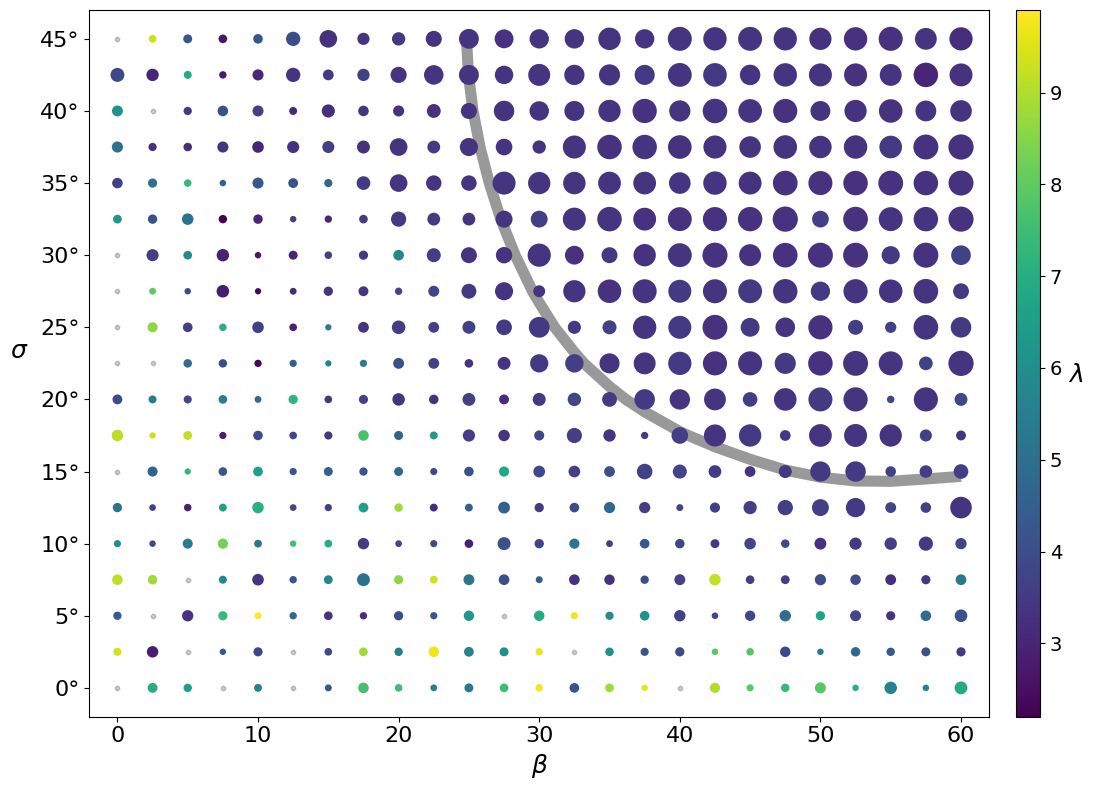

In [5]:
sigmas = np.linspace(0, 45, 19)
betas  = np.linspace(0, 60, 25)
repeat = 1
X, Y = np.meshgrid(betas, sigmas)
resolution = 10
image = np.zeros((len(sigmas), len(betas)))

paths = [[0*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [100*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [200*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [300*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)],
         [400*np.ones(np.shape(deviation)[0]-1), np.arange(0, np.shape(deviation)[0]-1)]]

# 1. Get a smoothed image to plot the Cbar ~ 0.8 contour
for i, sigma in enumerate(sigmas): 
    for j, beta in enumerate(betas): 

        #[mean_coherence, corr, prominence, lag, temp_entropy, angle_coh]
        metrics = np.load(f'fig07/{sigma}_{beta}_{repeat}_metrics.npy')
        image[i,j] = metrics[0]
smoothed_image = gaussian_filter(image, sigma=2.5)

# 2. Run the autocorrelation analysis on each surface to acquire correlation and lag
xs, ys, lags, corrs = [], [], [], []
nanxs, nanys = [], []

for sigma in sigmas:
    for beta in betas:
        # metrics = [mean_coherence, corr, prominence, lag, temp_entropy, angle_coh]
        deviation = np.load(f'fig07/{sigma}_{beta}_{repeat}.npy')
        corr, prominence, lag = compute_ac(deviation, paths)  
        xs.append(sigma)
        ys.append(beta)
        corrs.append(corr)  # size
        lags.append(lag/resolution)   # color
        if np.isnan(lag):
            nanxs.append(sigma)
            nanys.append(beta)

xs, ys = np.array(xs), np.array(ys)
nanxs, nanys = np.array(nanxs), np.array(nanys)
corrs   = np.array(corrs)
lags    = np.array(lags)

# Map corr -> marker area (points^2).
corr_min, corr_max = 0, 1
sizes = 20 + 340 * (corrs - corr_min) / (corr_max - corr_min)

fig, ax = plt.subplots(figsize=(12, 8))

# One scatter call so the colorbar works across all points
sc = ax.scatter(ys, xs, c=lags, s=sizes, cmap='viridis', vmin=np.nanmin(lags), vmax=np.nanmax(lags),
                edgecolors='none')  # marker='s' gives a grid/heatmap vibe
ax.scatter(nanys, nanxs, c='k', s=10, alpha=0.2)

#cbar = fig.colorbar(sc, ax=ax)
cbar = fig.colorbar(sc, ax=ax, aspect=30, location='right', pad=0.025)
cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$\lambda$', fontsize=18, rotation=0, labelpad=10) 

cs = plt.contour(
    X, Y, 
    smoothed_image, 
    levels=[0.8],      # the coherence level of interest
    colors='black', 
    linewidths=8,
    alpha=0.4,
    zorder=0
)

plt.ylim(-2, 47)
plt.xlim(-2, 62)

plt.xlabel(r'$\beta$', fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel(r'$\sigma$', fontsize=18, rotation=0, labelpad=15)
custom_labels = ['0°', '5°', '10°', '15°', '20°', '25°', '30°', '35°', '40°', '45°']
plt.yticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45], labels=custom_labels, fontsize=16)

plt.tight_layout()
plt.show()


(-0.6, 3.0)

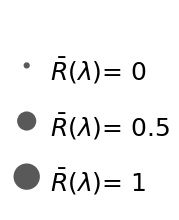

In [6]:
# --- match your panel's R range and size mapping ---
R_min, R_max = 0.0, 1.0          # <-- set to your actual min/max R
def size_map(R):
    return 20 + 340 * (R - R_min) / (R_max - R_min + 1e-12)  # same as main plot

# representative values to show in the legend
R_vals = np.array([R_min, 0.5*(R_min+R_max), R_max])         # e.g., [0.0, 0.5, 1.0]
sizes  = size_map(R_vals)

MARKER = 'o'   # use 's' if your main scatter uses squares
COLOR  = '0.35'

fig, ax = plt.subplots(figsize=(1.4, 2.6))
ax.axis('off')
y = np.arange(len(R_vals)-1, -1, -1, dtype=float)
for yi, si, Ri in zip(y, sizes, R_vals):
    ax.scatter(0, yi, s=si, c=COLOR, edgecolors='none', marker=MARKER)
    ax.text(0.55, yi-.1, r'$\bar{R}(\lambda)$' + f'= {Ri:.2g}', ha='left', va='center', fontsize=18)
#ax.text(0, y[0]+0.6, 'marker size ∝ R', ha='center', va='bottom', fontsize=11)
ax.set_xlim(-0.4, 2.2); ax.set_ylim(-0.6, y[0]+1.0)
# plt.savefig('legend_R_size_vertical.svg', bbox_inches='tight', pad_inches=0.02, transparent=True)



What is the average lag/wavelength of simulations with $\bar{C} >= 0.8$?

In [7]:
cohs, lags = [], []

for sigma in sigmas:
    for beta in betas:
        deviation = np.load(f'fig07/{sigma}_{beta}_{repeat}.npy')
        corr, prominence, lag = compute_ac(deviation, paths, plot=False)  
        metrics = np.load(f'fig07/{sigma}_{beta}_{repeat}_metrics.npy')
        cohs.append(metrics[0])  
        lags.append(lag/resolution)  

cohs, lags = np.array(cohs), np.array(lags)
temp = lags[cohs >= 0.8]
print(np.mean(temp))

3.388732394366197


In [8]:
np.std(temp)

np.float64(0.08888875112951924)